# Pipeline MCTNet — California (Table 2 exacte)
## ÉTAPE 1 : Alignement CDL → ÉTAPE 2 : Cube spectral 10 bandes → ÉTAPE 3 : MCT-Net

> **Structure attendue :**
> ```
> data/
>   raw/
>     californiaX.SAFE   ← tes archives .SAFE
>   processed/
>     cdl_california_2021.tif
> models/
> ```

---
### ✅ CORRECTIONS apportées
1. **Double CDL corrigé** : chaque zone (SGH, SFH) est extraite avec sa propre grille — le CDL n'est plus aligné deux fois sur la même image.
2. **`Nb of Samples` = total sélectionné** (train+val+test) comme dans le papier, pas les pixels disponibles.
3. **Split conforme à Table 2** : Train=240, Val=60, Test=reste jusqu'à 10 000.
4. **Extraction spectrale corrigée** : pixels SGH lus depuis la grille SGH, pixels SFH depuis la grille SFH.
5. **Chargement MCT-Net corrigé** : split train/val/test **explicite** (pas sklearn random split) pour respecter la Table 2.

## 📦 Imports

In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling as WarpResampling
from rasterio.enums import Resampling
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi']        = 130
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid']         = True
plt.rcParams['grid.alpha']        = 0.4
plt.rcParams['grid.linestyle']    = '--'

print(f'PyTorch  : {torch.__version__}')
print(f'Rasterio : {rasterio.__version__}')
print(f'GPU dispo: {"✅ " + torch.cuda.get_device_name(0) if torch.cuda.is_available() else "⚠️  CPU uniquement"}')
print('✓ Imports OK')

PyTorch  : 2.11.0+cpu
Rasterio : 1.4.4
GPU dispo: ⚠️  CPU uniquement
✓ Imports OK


## ⚙️ Configuration — À MODIFIER selon ton projet

In [2]:
# ── Chemins principaux ───────────────────────────────────────────────────────
DATA_DIR      = Path('data')
SAFE_DIR      = DATA_DIR / 'raw'
CDL_INPUT     = DATA_DIR / 'processed' / 'cdl_california_2021.tif'
PROCESSED_DIR = DATA_DIR / 'processed'
MODEL_DIR     = Path('models')

# ── Fichiers CDL alignés par zone ────────────────────────────────────────────
CDL_ALIGNED = {
    'SGH': PROCESSED_DIR / 'california_sgh.tif',
    'SFH': PROCESSED_DIR / 'california_sfh.tif',
    'SFG': PROCESSED_DIR / 'california_sfg.tif',
    'SFJ': PROCESSED_DIR / 'california_sfj.tif',
}

TRAIN_CSV  = PROCESSED_DIR / 'mctnet_train_data_10bands.csv'
MODEL_PATH = MODEL_DIR / 'mctnet_multispectral_final.pth'

# ── Bandes de référence S2 (une par zone) ────────────────────────────────────
S2_REF = {
    'SGH': SAFE_DIR / 'california1.SAFE/GRANULE/L2A_T10SGH_A022833_20210720T185324/IMG_DATA/R10m/T10SGH_20210720T183919_B04_10m.jp2',
    'SFH': SAFE_DIR / 'california10.SAFE/GRANULE/L2A_T10SFH_A022876_20210723T185617/IMG_DATA/R10m/T10SFH_20210723T184919_B04_10m.jp2',
    'SFG': SAFE_DIR / 'california8.SAFE/GRANULE/L2A_T10SFG_A022876_20210723T185617/IMG_DATA/R10m/T10SFG_20210723T184919_B04_10m.jp2',
    'SFJ': SAFE_DIR / 'california9.SAFE/GRANULE/L2A_T10SFJ_A022876_20210723T185617/IMG_DATA/R10m/T10SFJ_20210723T184919_B04_10m.jp2',
}

# ── Mapping des dates ─────────────────────────────────────────────────────────
# ✅ FIX CRITIQUE : zones SFG et SFJ corrigées (étaient toutes 'SGH' avant !)
DATES_MAP = {
    'july_sgh':  ('california1.SAFE',  'L2A_T10SGH_A022833_20210720T185324', 'T10SGH_20210720T183919', 'SGH'),
    'july_sgh2': ('california2.SAFE',  'L2A_T10SGH_A022833_20210720T185324', 'T10SGH_20210720T183919', 'SGH'),
    'jan_sgh':   ('california3.SAFE',  'L2A_T10SGH_A029239_20210126T184719', 'T10SGH_20210126T184641', 'SGH'),
    'sept_sgh':  ('california4.SAFE',  'L2A_T10SGH_A023734_20210921T185231', 'T10SGH_20210921T184959', 'SGH'),
    'jan_sfg':   ('california5.SAFE',  'L2A_T10SFG_A029239_20210126T184719', 'T10SFG_20210126T184641', 'SFG'),
    'sept_sfg':  ('california6.SAFE',  'L2A_T10SFG_A032714_20210926T185622', 'T10SFG_20210926T185131', 'SFG'),
    'apr_sfg':   ('california7.SAFE',  'L2A_T10SFG_A030426_20210419T190327', 'T10SFG_20210419T184911', 'SFG'),
    'july_sfg':  ('california8.SAFE',  'L2A_T10SFG_A022876_20210723T185617', 'T10SFG_20210723T184919', 'SFG'),
    'july_sfj':  ('california9.SAFE',  'L2A_T10SFJ_A022876_20210723T185617', 'T10SFJ_20210723T184919', 'SFJ'),
    'july_sfh':  ('california10.SAFE', 'L2A_T10SFH_A022876_20210723T185617', 'T10SFH_20210723T184919', 'SFH'),
}

# ── Bandes spectrales ─────────────────────────────────────────────────────────
BANDS_10M = ['B02', 'B03', 'B04', 'B08']
BANDS_20M = ['B05', 'B06', 'B07', 'B8A', 'B11', 'B12']
ALL_BANDS  = BANDS_10M + BANDS_20M  # 10 bandes

# ── Hyperparamètres ───────────────────────────────────────────────────────────
N_DATES           = len(DATES_MAP)
N_BANDS           = 10
TOTAL_SAMPLES     = 10_000
N_TRAIN_PER_CLASS = 240
N_VAL_PER_CLASS   = 60
N_CLASSES         = 6
BATCH_SIZE        = 512
LR                = 0.0005
EPOCHS            = 50
RANDOM_STATE      = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ALL_ZONES = sorted(set(v[3] for v in DATES_MAP.values()))

print('=== Vérification des chemins ===')
for zone in ALL_ZONES:
    p = S2_REF[zone]
    print(f'  {"✅" if Path(p).exists() else "❌ INTROUVABLE"}  Réf {zone} : {p}')
print(f'  {"✅" if CDL_INPUT.exists() else "❌ INTROUVABLE"}  CDL brut : {CDL_INPUT}')
print(f'\n  Device  : {DEVICE}')
print(f'  Dates   : {list(DATES_MAP.keys())}')
print(f'  Zones   : {ALL_ZONES}')
print(f'  N_DATES : {N_DATES}  |  Features : {N_DATES} × {N_BANDS} = {N_DATES * N_BANDS} colonnes')


=== Vérification des chemins ===
  ✅  Réf SFG : data\raw\california8.SAFE\GRANULE\L2A_T10SFG_A022876_20210723T185617\IMG_DATA\R10m\T10SFG_20210723T184919_B04_10m.jp2
  ✅  Réf SFH : data\raw\california10.SAFE\GRANULE\L2A_T10SFH_A022876_20210723T185617\IMG_DATA\R10m\T10SFH_20210723T184919_B04_10m.jp2
  ✅  Réf SFJ : data\raw\california9.SAFE\GRANULE\L2A_T10SFJ_A022876_20210723T185617\IMG_DATA\R10m\T10SFJ_20210723T184919_B04_10m.jp2
  ✅  Réf SGH : data\raw\california1.SAFE\GRANULE\L2A_T10SGH_A022833_20210720T185324\IMG_DATA\R10m\T10SGH_20210720T183919_B04_10m.jp2
  ✅  CDL brut : data\processed\cdl_california_2021.tif

  Device  : cpu
  Dates   : ['july_sgh', 'july_sgh2', 'jan_sgh', 'sept_sgh', 'jan_sfg', 'sept_sfg', 'apr_sfg', 'july_sfg', 'july_sfj', 'july_sfh']
  Zones   : ['SFG', 'SFH', 'SFJ', 'SGH']
  N_DATES : 10  |  Features : 10 × 10 = 100 colonnes


---
# ÉTAPE 1 — Alignement CDL
### ✅ FIX : Alignement sur DEUX grilles distinctes (SGH et SFH)

In [3]:
import gc
gc.collect()

def align_cdl_to_s2(s2_ref_path, cdl_input_path, output_path, zone_name):
    """Reprojette le CDL sur la grille exacte d'une tuile Sentinel-2."""
    if not Path(s2_ref_path).exists():
        print(f'  ⚠️  Bande réf introuvable pour {zone_name} — SKIP')
        return None, None, None

    print(f'=== Alignement CDL Zone {zone_name} ===')
    with rasterio.open(s2_ref_path) as s2:
        dst_crs       = s2.crs
        dst_transform = s2.transform
        profile       = s2.profile.copy()
        print(f'  CRS    : {dst_crs}')
        print(f'  Bounds : {s2.bounds}')

    profile.update({'dtype': 'uint16', 'count': 1, 'nodata': 0, 'driver': 'GTiff'})
    if output_path.exists():
        output_path.unlink()

    with rasterio.open(cdl_input_path) as src:
        with rasterio.open(output_path, 'w', **profile) as dst:
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform, src_crs=src.crs,
                dst_transform=dst_transform, dst_crs=dst_crs,
                resampling=WarpResampling.nearest
            )
    print(f'✅ CDL {zone_name} aligné → {output_path}\n')
    return profile, dst_transform, dst_crs

# ✅ FIX : Alignement sur TOUTES les zones (SGH, SFH, SFG, SFJ)
zone_profiles = {}
print(f'Zones à aligner : {ALL_ZONES}\n')
for zone in ALL_ZONES:
    p, t, c = align_cdl_to_s2(S2_REF[zone], CDL_INPUT, CDL_ALIGNED[zone], zone)
    zone_profiles[zone] = {'ok': p is not None, 'profile': p, 'transform': t, 'crs': c}

print('\nRésumé alignement :')
for zone, info in zone_profiles.items():
    print(f'  {"✅" if info["ok"] else "❌"}  {zone}')


Zones à aligner : ['SFG', 'SFH', 'SFJ', 'SGH']

=== Alignement CDL Zone SFG ===
  CRS    : EPSG:32610
  Bounds : BoundingBox(left=600000.0, bottom=4090200.0, right=709800.0, top=4200000.0)
✅ CDL SFG aligné → data\processed\california_sfg.tif

=== Alignement CDL Zone SFH ===
  CRS    : EPSG:32610
  Bounds : BoundingBox(left=600000.0, bottom=4190220.0, right=709800.0, top=4300020.0)
✅ CDL SFH aligné → data\processed\california_sfh.tif

=== Alignement CDL Zone SFJ ===
  CRS    : EPSG:32610
  Bounds : BoundingBox(left=600000.0, bottom=4290240.0, right=709800.0, top=4400040.0)
✅ CDL SFJ aligné → data\processed\california_sfj.tif

=== Alignement CDL Zone SGH ===
  CRS    : EPSG:32610
  Bounds : BoundingBox(left=699960.0, bottom=4190220.0, right=809760.0, top=4300020.0)
✅ CDL SGH aligné → data\processed\california_sgh.tif


Résumé alignement :
  ✅  SFG
  ✅  SFH
  ✅  SFJ
  ✅  SGH


### 🔍 Inspection du CDL aligné

=== CDL SGH aligné ===
  CRS    : EPSG:32610
  Taille : 10980 × 10980 px
  Classes agricoles : 55
  Pixels agricoles  : 120,560,400


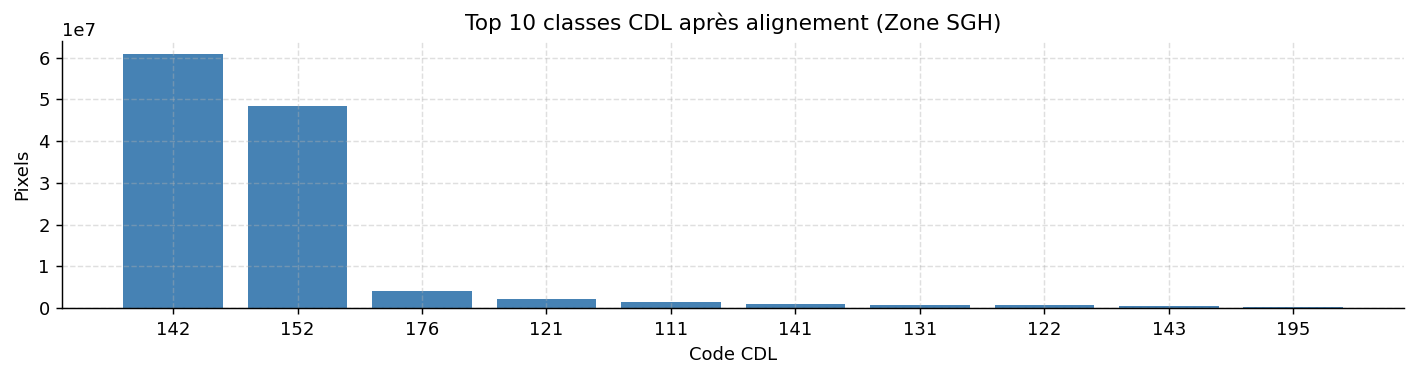


✅ Étape 1 terminée — CDL aligné OK


In [4]:
with rasterio.open(CDL_ALIGNED['SGH']) as dst:
    print('=== CDL SGH aligné ===')
    print(f'  CRS    : {dst.crs}')
    print(f'  Taille : {dst.width} × {dst.height} px')
    cdl_check = dst.read(1)

unique_cls, counts_cls = np.unique(cdl_check[cdl_check > 0], return_counts=True)
print(f'  Classes agricoles : {len(unique_cls)}')
print(f'  Pixels agricoles  : {counts_cls.sum():,}')

fig, ax = plt.subplots(figsize=(11, 3))
top10 = sorted(zip(counts_cls, unique_cls), reverse=True)[:10]
top_cnt, top_cls = zip(*top10)
ax.bar([str(int(c)) for c in top_cls], top_cnt, color='steelblue')
ax.set_title('Top 10 classes CDL après alignement (Zone SGH)')
ax.set_xlabel('Code CDL'); ax.set_ylabel('Pixels')
plt.tight_layout(); plt.show()
print('\n✅ Étape 1 terminée — CDL aligné OK')


---
# ÉTAPE 2 — Échantillonnage 10 000 pixels (Table 2)
### ✅ FIX : `Nb of Samples` = total sélectionné (train+val+test), pas les pixels disponibles

In [5]:
# ── Mapping CDL — Classes California ─────────────────────────────────────────
CALIFORNIA_CLASSES = {
    'Grapes'     : [87, 214, 217, 239, 241, 242, 245, 246, 250, 252],
    'Rice'       : [3, 238],
    'Alfalfa'    : [36, 225, 240],
    'Almonds'    : [68, 243, 254],
    'Pistachios' : [76, 204, 244],
}
CODE_TO_CLASS = {}
for class_name, codes in CALIFORNIA_CLASSES.items():
    for c in codes:
        CODE_TO_CLASS[c] = class_name

print('✅ Classes California définies :')
for cls, codes in CALIFORNIA_CLASSES.items():
    print(f'   {cls:<12} → codes CDL : {codes}')
print(f'   {"Others":<12} → tous les autres codes agricoles')

✅ Classes California définies :
   Grapes       → codes CDL : [87, 214, 217, 239, 241, 242, 245, 246, 250, 252]
   Rice         → codes CDL : [3, 238]
   Alfalfa      → codes CDL : [36, 225, 240]
   Almonds      → codes CDL : [68, 243, 254]
   Pistachios   → codes CDL : [76, 204, 244]
   Others       → tous les autres codes agricoles


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# 📊 Extraction pixels par classe — rapide et correcte par zone
# ✅ FIX VITESSE : on stocke (rows_arr, cols_arr, zones_arr) en numpy, plus de list(zip)
# ══════════════════════════════════════════════════════════════════════════════

def extract_pixels_by_zone(cdl_path):
    """Retourne rows, cols, labels (np arrays) et shape pour une zone."""
    with rasterio.open(cdl_path) as src:
        labels = src.read(1)
    mask = labels > 0
    rows, cols = np.where(mask)
    return rows, cols, labels[rows, cols], labels.shape

# Extraire toutes les zones disponibles
zone_data = {}   # zone -> {rows, cols, labels, shape}
for zone in ALL_ZONES:
    if zone_profiles[zone]['ok']:
        r, c, l, sh = extract_pixels_by_zone(CDL_ALIGNED[zone])
        zone_data[zone] = {'rows': r, 'cols': c, 'labels': l, 'shape': sh}
        print(f'Zone {zone} : {len(r):,} pixels agricoles (grille {sh})')
    else:
        print(f'Zone {zone} : ⚠️ CDL non disponible — ignorée')

# ── Grouper pixels par classe via numpy (pas de list(zip) = rapide) ──────────
CALIFORNIA_CLASSES = {
    'Grapes'     : [87, 214, 217, 239, 241, 242, 245, 246, 250, 252],
    'Rice'       : [3, 238],
    'Alfalfa'    : [36, 225, 240],
    'Almonds'    : [68, 243, 254],
    'Pistachios' : [76, 204, 244],
}
CODE_TO_CLASS = {}
for cn, codes in CALIFORNIA_CLASSES.items():
    for c in codes:
        CODE_TO_CLASS[c] = cn

ORDER = ['Grapes', 'Rice', 'Alfalfa', 'Almonds', 'Pistachios', 'Others']

# Construire des arrays numpy par classe — toutes zones confondues
# Structure : {cls: {'rows': np, 'cols': np, 'zones': np(str)}}
class_data = {cls: {'rows': [], 'cols': [], 'zones': []} for cls in ORDER}

for zone, zd in zone_data.items():
    lbl_int = zd['labels'].astype(np.int32)
    unique_codes = np.unique(lbl_int)
    for code in unique_codes:
        cls = CODE_TO_CLASS.get(int(code), 'Others')
        mask = lbl_int == code
        class_data[cls]['rows'].append(zd['rows'][mask])
        class_data[cls]['cols'].append(zd['cols'][mask])
        class_data[cls]['zones'].append(np.full(mask.sum(), zone))

# Concaténer en arrays numpy
for cls in ORDER:
    d = class_data[cls]
    if d['rows']:
        class_data[cls]['rows']  = np.concatenate(d['rows'])
        class_data[cls]['cols']  = np.concatenate(d['cols'])
        class_data[cls]['zones'] = np.concatenate(d['zones'])
    else:
        class_data[cls]['rows']  = np.array([], dtype=np.int64)
        class_data[cls]['cols']  = np.array([], dtype=np.int64)
        class_data[cls]['zones'] = np.array([], dtype=str)

print('\nPixels disponibles par classe :')
for cls in ORDER:
    n  = len(class_data[cls]['rows'])
    ok = '✅' if n >= N_TRAIN_PER_CLASS + N_VAL_PER_CLASS + 1 else '❌ INSUFFISANT'
    print(f'  {ok}  {cls:<12} : {n:>12,} px')


Zone SFG : 120,560,400 pixels agricoles (grille (10980, 10980))
Zone SFH : 120,560,400 pixels agricoles (grille (10980, 10980))
Zone SFJ : 120,560,400 pixels agricoles (grille (10980, 10980))
Zone SGH : 120,560,400 pixels agricoles (grille (10980, 10980))

Pixels disponibles par classe :
  ✅  Grapes       :       44,331 px
  ✅  Rice         :    9,998,323 px
  ✅  Alfalfa      :   12,182,065 px
  ✅  Almonds      :      271,855 px
  ✅  Pistachios   :   10,848,945 px
  ✅  Others       :  448,896,081 px


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# Échantillonnage EXACTEMENT 10 000 pixels — indexing numpy rapide
# ✅ FIX VITESSE : plus de boucle 'for i in sidx: records.append(...)'
# ══════════════════════════════════════════════════════════════════════════════

N_MIN_PER_CLASS = N_TRAIN_PER_CLASS + N_VAL_PER_CLASS + 1

rng = np.random.default_rng(RANDOM_STATE)
test_budget = TOTAL_SAMPLES - N_CLASSES * (N_TRAIN_PER_CLASS + N_VAL_PER_CLASS)
cuts = np.sort(rng.choice(test_budget - N_CLASSES + 1, N_CLASSES - 1, replace=False))
cuts = np.concatenate([[0], cuts + np.arange(1, N_CLASSES), [test_budget]])
test_sizes = np.diff(cuts).astype(int)
assert test_sizes.sum() == test_budget

all_rows, all_cols, all_zones, all_labels, all_splits = [], [], [], [], []
table_rows = []
total_count = 0

for k, cls in enumerate(ORDER):
    d      = class_data[cls]
    n_avail = len(d['rows'])
    n_test  = min(int(test_sizes[k]), n_avail - N_TRAIN_PER_CLASS - N_VAL_PER_CLASS)

    if n_avail < N_MIN_PER_CLASS:
        print(f'  ⚠️  {cls} ignorée ({n_avail} px < {N_MIN_PER_CLASS} minimum)')
        continue

    idx    = rng.permutation(n_avail)
    tr_idx = idx[:N_TRAIN_PER_CLASS]
    v_idx  = idx[N_TRAIN_PER_CLASS : N_TRAIN_PER_CLASS + N_VAL_PER_CLASS]
    te_idx = idx[N_TRAIN_PER_CLASS + N_VAL_PER_CLASS : N_TRAIN_PER_CLASS + N_VAL_PER_CLASS + n_test]

    for sidx, split_name in [(tr_idx, 'train'), (v_idx, 'val'), (te_idx, 'test')]:
        n = len(sidx)
        all_rows.append(d['rows'][sidx])
        all_cols.append(d['cols'][sidx])
        all_zones.append(d['zones'][sidx])
        all_labels.append(np.full(n, cls))
        all_splits.append(np.full(n, split_name))

    class_total = N_TRAIN_PER_CLASS + N_VAL_PER_CLASS + n_test
    total_count += class_total
    table_rows.append({'Class Name': cls, 'Nb of Samples': class_total,
                       'Training': N_TRAIN_PER_CLASS, 'Validation': N_VAL_PER_CLASS,
                       'Testing': n_test})

assert total_count == TOTAL_SAMPLES, f'Total={total_count}, attendu {TOTAL_SAMPLES}'

df_records = pd.DataFrame({
    'row'  : np.concatenate(all_rows),
    'col'  : np.concatenate(all_cols),
    'zone' : np.concatenate(all_zones),
    'label': np.concatenate(all_labels),
    'split': np.concatenate(all_splits),
})

n_tr = (df_records['split']=='train').sum()
n_vl = (df_records['split']=='val').sum()
n_te = (df_records['split']=='test').sum()
print(f'✅ TOTAL EXACT : {total_count:,} pixels')
print(f'  Train : {n_tr:,}  |  Val : {n_vl:,}  |  Test : {n_te:,}')
for zone in ALL_ZONES:
    n = (df_records['zone']==zone).sum()
    print(f'  Zone {zone} : {n:,} px')


✅ TOTAL EXACT : 10,000 pixels
  Train : 1,440  |  Val : 360  |  Test : 8,200
  Zone SFG : 2,387 px
  Zone SFH : 3,145 px
  Zone SFJ : 3,741 px
  Zone SGH : 727 px


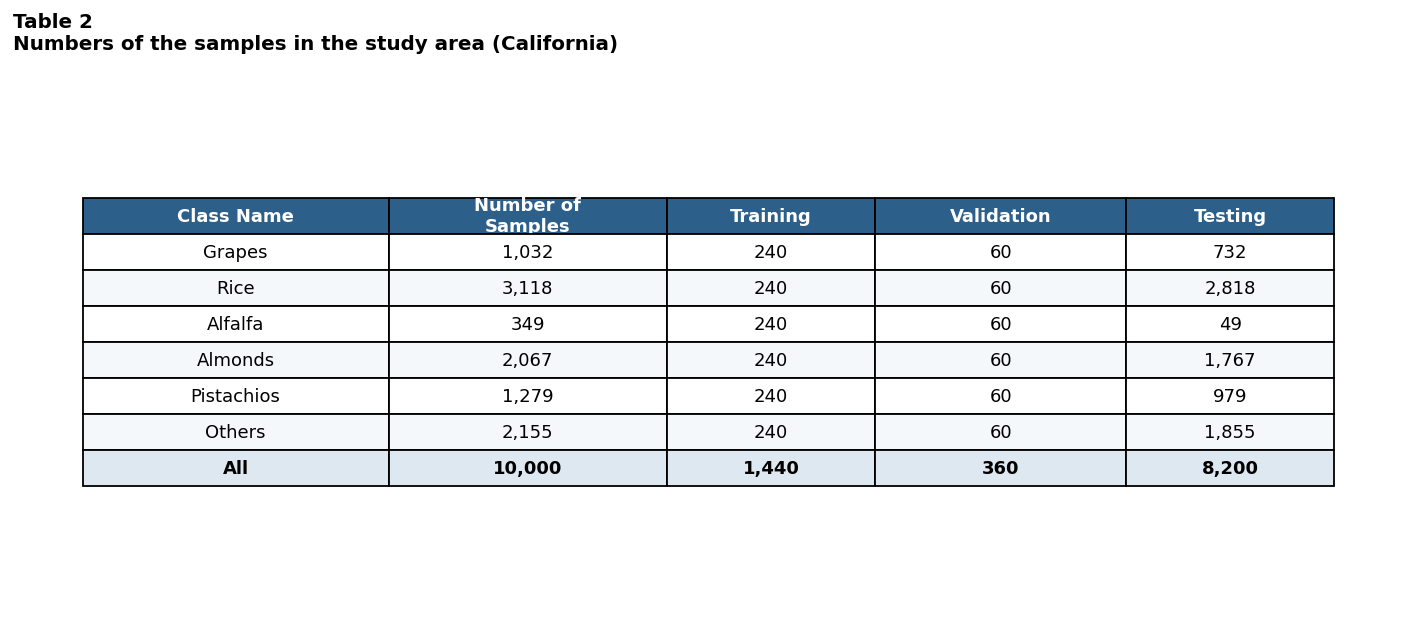

Class Name  Nb of Samples  Training  Validation  Testing
    Grapes           1032       240          60      732
      Rice           3118       240          60     2818
   Alfalfa            349       240          60       49
   Almonds           2067       240          60     1767
Pistachios           1279       240          60      979
    Others           2155       240          60     1855
       All          10000      1440         360     8200


In [8]:
# ── Affichage Table 2 (style papier) ─────────────────────────────────────────
df_table  = pd.DataFrame(table_rows)
total_row = {
    'Class Name'    : 'All',
    'Nb of Samples' : df_table['Nb of Samples'].sum(),
    'Training'      : df_table['Training'].sum(),
    'Validation'    : df_table['Validation'].sum(),
    'Testing'       : df_table['Testing'].sum(),
}
df_display = pd.concat([df_table, pd.DataFrame([total_row])], ignore_index=True)

fig, ax = plt.subplots(figsize=(11, 0.55 * (len(df_display) + 2)))
ax.axis('off')
col_labels = ['Class Name', 'Number of\nSamples', 'Training', 'Validation', 'Testing']
col_widths = [0.22, 0.20, 0.15, 0.18, 0.15]
cell_data = [
    [row['Class Name'],
     f'{int(row["Nb of Samples"]):,}',
     f'{int(row["Training"]):,}',
     f'{int(row["Validation"]):,}',
     f'{int(row["Testing"]):,}']
    for _, row in df_display.iterrows()
]
tbl = ax.table(cellText=cell_data, colLabels=col_labels,
               colWidths=col_widths, loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 1.5)
for j in range(len(col_labels)):
    tbl[0, j].set_facecolor('#2c5f8a')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
last = len(cell_data)
for j in range(len(col_labels)):
    tbl[last, j].set_facecolor('#dde8f0')
    tbl[last, j].set_text_props(fontweight='bold')
for i in range(1, last):
    c = '#f4f8fb' if i % 2 == 0 else 'white'
    for j in range(len(col_labels)): tbl[i, j].set_facecolor(c)
ax.set_title('Table 2\nNumbers of the samples in the study area (California)',
             fontsize=11, fontweight='bold', loc='left', pad=10)
plt.tight_layout(); plt.show()
print(df_display.to_string(index=False))

---
# ÉTAPE 2b — Extraction spectrale
### 🔧 Fonction get_band_path

In [9]:
def get_band_path(safe_dir_name, granule_dir, file_prefix, band, res):
    dir_path = SAFE_DIR / safe_dir_name / 'GRANULE' / granule_dir / 'IMG_DATA' / f'R{res}m'
    filename = f'{file_prefix}_{band}_{res}m.jp2'
    return dir_path / filename

print('Vérification des bandes B04 :')
for date_name, (safe_dir, granule_dir, file_prefix, zone) in DATES_MAP.items():
    path = get_band_path(safe_dir, granule_dir, file_prefix, 'B04', 10)
    status = '✅' if path.exists() else '❌'
    print(f'  {status} {date_name:12} [{zone}] → {path.name}')

Vérification des bandes B04 :
  ✅ july_sgh     [SGH] → T10SGH_20210720T183919_B04_10m.jp2
  ✅ july_sgh2    [SGH] → T10SGH_20210720T183919_B04_10m.jp2
  ✅ jan_sgh      [SGH] → T10SGH_20210126T184641_B04_10m.jp2
  ✅ sept_sgh     [SGH] → T10SGH_20210921T184959_B04_10m.jp2
  ✅ jan_sfg      [SFG] → T10SFG_20210126T184641_B04_10m.jp2
  ✅ sept_sfg     [SFG] → T10SFG_20210926T185131_B04_10m.jp2
  ✅ apr_sfg      [SFG] → T10SFG_20210419T184911_B04_10m.jp2
  ✅ july_sfg     [SFG] → T10SFG_20210723T184919_B04_10m.jp2
  ✅ july_sfj     [SFJ] → T10SFJ_20210723T184919_B04_10m.jp2
  ✅ july_sfh     [SFH] → T10SFH_20210723T184919_B04_10m.jp2


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# Extraction spectrale — chaque pixel lu sur sa propre grille de zone
# ✅ FIX VITESSE : indexing numpy direct, plus de df.loc ligne à ligne
# ✅ FIX ZONES   : SGH / SFH / SFG / SFJ toutes gérées
# ══════════════════════════════════════════════════════════════════════════════

# Préparer les indices par zone
zone_masks = {zone: (df_records['zone'] == zone).values for zone in ALL_ZONES}
zone_rows  = {zone: df_records['row'].values[zone_masks[zone]] for zone in ALL_ZONES}
zone_cols  = {zone: df_records['col'].values[zone_masks[zone]] for zone in ALL_ZONES}

for zone in ALL_ZONES:
    n = zone_masks[zone].sum()
    print(f'Zone {zone} : {n:,} pixels à extraire')

# Tableau résultat en numpy — bien plus rapide que DataFrame.loc
n_pixels  = len(df_records)
n_features = N_DATES * N_BANDS
feat_matrix = np.full((n_pixels, n_features), np.nan, dtype=np.float32)
feat_names  = []

col_idx = 0
for date_name, (safe_dir_name, granule_dir, file_prefix, zone) in DATES_MAP.items():
    print(f'\n📅 {date_name.upper()}  [{zone}]')

    if not zone_profiles.get(zone, {}).get('ok', False):
        print(f'  ⚠️  Zone {zone} non alignée — colonnes NaN')
        for band in ALL_BANDS:
            feat_names.append(f'{band}_{date_name}')
            col_idx += 1
        continue

    zmask = zone_masks[zone]
    rows_z = zone_rows[zone]
    cols_z = zone_cols[zone]
    shape_z = zone_data[zone]['shape']

    if zmask.sum() == 0:
        print(f'  ⚠️  Aucun pixel — skip')
        for band in ALL_BANDS:
            feat_names.append(f'{band}_{date_name}')
            col_idx += 1
        continue

    for band in ALL_BANDS:
        res  = 10 if band in BANDS_10M else 20
        path = SAFE_DIR / safe_dir_name / 'GRANULE' / granule_dir / 'IMG_DATA' / f'R{res}m' / f'{file_prefix}_{band}_{res}m.jp2'
        feat_names.append(f'{band}_{date_name}')
        if not path.exists():
            print(f'  ❌ {band}', end=' | ')
            col_idx += 1
            continue
        with rasterio.open(path) as src:
            data = src.read(1, out_shape=shape_z, resampling=Resampling.bilinear)
            feat_matrix[zmask, col_idx] = data[rows_z, cols_z].astype(np.float32)
        print(f'  ✅ {band}', end=' | ')
        col_idx += 1
    print()

print(f'\nDimensions : {n_pixels} pixels × {len(feat_names)} features')
nan_count = np.isnan(feat_matrix).sum()
print(f'NaN total : {nan_count:,}  ({100*nan_count/(n_pixels*n_features):.1f}%)')


Zone SFG : 2,387 pixels à extraire
Zone SFH : 3,145 pixels à extraire
Zone SFJ : 3,741 pixels à extraire
Zone SGH : 727 pixels à extraire

📅 JULY_SGH  [SGH]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 JULY_SGH2  [SGH]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 JAN_SGH  [SGH]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 SEPT_SGH  [SGH]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 JAN_SFG  [SFG]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 SEPT_SFG  [SFG]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 APR_SFG  [SFG]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 JULY_SFG  [SFG]
  ✅ B

In [11]:
# ── Construction df_final + sauvegarde CSV ───────────────────────────────────
df_final = pd.DataFrame(feat_matrix, columns=feat_names)
df_final.insert(0, 'crop_label', df_records['label'].values)
df_final.insert(1, 'split',      df_records['split'].values)

df_final.to_csv(TRAIN_CSV, index=False)
size_mb = TRAIN_CSV.stat().st_size / 1e6
print(f'✅ CSV sauvegardé : {TRAIN_CSV}  ({size_mb:.1f} MB)')
print(f'   {len(df_final):,} pixels × {df_final.shape[1]} colonnes')
print(f'   Colonnes : {list(df_final.columns[:5])} ... {list(df_final.columns[-3:])}')


✅ CSV sauvegardé : data\processed\mctnet_train_data_10bands.csv  (2.3 MB)
   10,000 pixels × 102 colonnes
   Colonnes : ['crop_label', 'split', 'B02_july_sgh', 'B03_july_sgh', 'B04_july_sgh'] ... ['B8A_july_sfh', 'B11_july_sfh', 'B12_july_sfh']


---
# ÉTAPE 3 — MCT-Net
### ✅ FIX : split Train/Val/Test depuis la colonne 'split' (pas sklearn random split)

In [12]:
print('Lecture du dataset...')
df = pd.read_csv(TRAIN_CSV)
print(f'  Lignes   : {len(df):,}')
print(f'  Colonnes : {df.shape[1]}')
print(f'  Classes  : {df["crop_label"].nunique()} cultures')
print(f'  Split    : {df["split"].value_counts().to_dict()}')

# Encodage labels
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['crop_label'])
num_classes = len(le.classes_)
print(f'\n  Classes encodées : {list(le.classes_)}')

# Feature columns
feat_cols = [c for c in df.columns if c not in ['crop_label', 'split', 'label_encoded']]
print(f'  Features : {len(feat_cols)} colonnes ({N_DATES} dates × {N_BANDS} bandes)')

# ✅ FIX 1 : Remplacer les NaN par la médiane (calculée sur le train uniquement)
train_mask = df['split'] == 'train'
nan_count  = df[feat_cols].isnull().sum().sum()
print(f'\n  NaN détectés : {nan_count:,}', end='')
if nan_count > 0:
    medians = df.loc[train_mask, feat_cols].median()
    df[feat_cols] = df[feat_cols].fillna(medians)
    print(f' → remplacés par la médiane du train')
else:
    print(' ✅')

# ✅ FIX 2 : StandardScaler fitté UNIQUEMENT sur le train
scaler = StandardScaler()
df.loc[train_mask,  feat_cols] = scaler.fit_transform(df.loc[train_mask, feat_cols])
df.loc[~train_mask, feat_cols] = scaler.transform(df.loc[~train_mask, feat_cols])

# ✅ FIX 3 : Vérification finale avant entraînement
nan_after = df[feat_cols].isnull().sum().sum()
inf_after = np.isinf(df[feat_cols].values).sum()
assert nan_after == 0, f'NaN restants : {nan_after}'
assert inf_after == 0, f'Inf restants : {inf_after}'
print(f'  ✅ Données propres — NaN: {nan_after}  Inf: {inf_after}')
print(f'  Plage features train : [{df.loc[train_mask, feat_cols].values.min():.3f}, {df.loc[train_mask, feat_cols].values.max():.3f}]')

# ── Split explicite depuis la colonne 'split' ─────────────────────────────────
def get_split(split_name):
    mask = df['split'] == split_name
    # ✅ Ordre colonnes explicite pour garantir reshape cohérent
    ordered_cols = [f'{b}_{d}' for d in DATES_MAP.keys() for b in ALL_BANDS]
    X = df.loc[mask, ordered_cols].values.reshape(-1, N_DATES, N_BANDS).astype('float32')
    y = df.loc[mask, 'label_encoded'].values.astype('int64')
    return X, y

X_train, y_train = get_split('train')
X_val,   y_val   = get_split('val')
X_test,  y_test  = get_split('test')

print(f'\n  X_train : {X_train.shape}  |  y_train : {y_train.shape}')
print(f'  X_val   : {X_val.shape}    |  y_val   : {y_val.shape}')
print(f'  X_test  : {X_test.shape}   |  y_test  : {y_test.shape}')

# ✅ Assertion sécurité tenseurs
assert not np.isnan(X_train).any(), '❌ NaN dans X_train!'
assert not np.isnan(X_val).any(),   '❌ NaN dans X_val!'
assert not np.isnan(X_test).any(),  '❌ NaN dans X_test!'
print('  ✅ Tenseurs vérifiés — aucun NaN')

train_data   = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_data     = TensorDataset(torch.from_numpy(X_val),   torch.from_numpy(y_val))
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
print(f'\n  Batches train/époque : {len(train_loader)}')


Lecture du dataset...
  Lignes   : 10,000
  Colonnes : 102
  Classes  : 6 cultures
  Split    : {'test': 8200, 'train': 1440, 'val': 360}

  Classes encodées : ['Alfalfa', 'Almonds', 'Grapes', 'Others', 'Pistachios', 'Rice']
  Features : 100 colonnes (10 dates × 10 bandes)

  NaN détectés : 806,580 → remplacés par la médiane du train
  ✅ Données propres — NaN: 0  Inf: 0
  Plage features train : [-10.307, 34.755]

  X_train : (1440, 10, 10)  |  y_train : (1440,)
  X_val   : (360, 10, 10)    |  y_val   : (360,)
  X_test  : (8200, 10, 10)   |  y_test  : (8200,)
  ✅ Tenseurs vérifiés — aucun NaN

  Batches train/époque : 3


### 🧠 Architecture MCT-Net (CNN 1D + Transformer Encoder)

In [13]:
class CNNTransformerMCTNet(nn.Module):
    """
    Modèle hybride CNN 1D + Transformer pour séries temporelles multi-spectrales.
    Flux : (B, N_DATES, N_BANDS) → CNN 1D → Transformer → GlobalAvgPool → Linear
    """
    def __init__(self, n_dates, n_bands, num_classes, cnn_filters=128, nhead=8, num_layers=3):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=n_bands, out_channels=cnn_filters, kernel_size=3, padding=1),
            nn.BatchNorm1d(cnn_filters),
            nn.ReLU()
        )
        encoder_layer    = nn.TransformerEncoderLayer(d_model=cnn_filters, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc          = nn.Linear(cnn_filters, num_classes)

    def forward(self, x):
        x = x.transpose(1, 2)    # (B, N_BANDS, N_DATES)
        x = self.cnn(x)           # (B, 128, N_DATES)
        x = x.transpose(1, 2)    # (B, N_DATES, 128)
        x = self.transformer(x)  # (B, N_DATES, 128)
        x = x.mean(dim=1)         # (B, 128)
        return self.fc(x)         # (B, num_classes)

model = CNNTransformerMCTNet(
    n_dates=N_DATES, n_bands=N_BANDS, num_classes=num_classes
).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f'✅ Modèle MCT-Net initialisé')
print(f'  Paramètres : {total_params:,}')
print(f'  Classes    : {num_classes}  ({list(le.classes_)})')
print(f'  Device     : {DEVICE}')

✅ Modèle MCT-Net initialisé
  Paramètres : 1,784,070
  Classes    : 6  (['Alfalfa', 'Almonds', 'Grapes', 'Others', 'Pistachios', 'Rice'])
  Device     : cpu


### 🏋️ Boucle d'entraînement (50 époques) avec validation

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
# ✅ Scheduler cosine — réduit le LR progressivement
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
history   = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

print(f'Entraînement MCT-Net — {num_classes} classes, entrée ({N_DATES} dates × {N_BANDS} bandes)')
print(f'Device : {DEVICE}  |  Batch : {BATCH_SIZE}  |  LR : {LR}  |  Époques : {EPOCHS}')
print(f'Optimizer : Adam (weight_decay=1e-4)  |  Scheduler : CosineAnnealing  |  GradClip : 1.0\n')

best_val_loss = float('inf')
best_state    = None

for epoch in range(EPOCHS):
    # ── Train ──────────────────────────────────────────────────────────────────
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    nan_batches = 0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(DEVICE), batch_y.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss    = criterion(outputs, batch_y)

        # ✅ Guard NaN : skip le batch si loss explose
        if torch.isnan(loss) or torch.isinf(loss):
            nan_batches += 1
            continue

        loss.backward()
        # ✅ Gradient clipping — évite les explosions de gradient
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total   += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()

    scheduler.step()
    tr_acc  = 100 * correct / total if total > 0 else 0.0
    tr_loss = total_loss / max(len(train_loader) - nan_batches, 1)

    # ── Validation ────────────────────────────────────────────────────────────
    model.eval()
    vl_loss, vl_correct, vl_total = 0.0, 0, 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(DEVICE), batch_y.to(DEVICE)
            outputs = model(batch_X)
            loss    = criterion(outputs, batch_y)
            vl_loss    += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            vl_total   += batch_y.size(0)
            vl_correct += (predicted == batch_y).sum().item()

    vl_acc  = 100 * vl_correct / vl_total
    vl_loss /= len(val_loader)

    history['loss'].append(tr_loss)
    history['accuracy'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_accuracy'].append(vl_acc)

    # ✅ Sauvegarde du meilleur modèle (early-stop implicite)
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if (epoch + 1) % 5 == 0 or epoch == 0:
        lr_cur = scheduler.get_last_lr()[0]
        nan_warn = f'  ⚠️ {nan_batches} batches NaN' if nan_batches else ''
        print(f'  Époque [{epoch+1:>2}/{EPOCHS}]  '
              f'Loss: {tr_loss:.4f}  Acc: {tr_acc:.2f}%  '
              f'| Val Loss: {vl_loss:.4f}  Val Acc: {vl_acc:.2f}%  '
              f'LR: {lr_cur:.6f}{nan_warn}')

# Recharger le meilleur modèle
if best_state is not None:
    model.load_state_dict(best_state)
    print(f'\n✅ Meilleur modèle rechargé (val_loss = {best_val_loss:.4f})')
print('✅ Entraînement terminé !')


Entraînement MCT-Net — 6 classes, entrée (10 dates × 10 bandes)
Device : cpu  |  Batch : 512  |  LR : 0.0005  |  Époques : 50
Optimizer : Adam (weight_decay=1e-4)  |  Scheduler : CosineAnnealing  |  GradClip : 1.0

  Époque [ 1/50]  Loss: 1.8561  Acc: 20.00%  | Val Loss: 1.8062  Val Acc: 28.89%  LR: 0.000500
  Époque [ 5/50]  Loss: 1.3696  Acc: 45.97%  | Val Loss: 1.4000  Val Acc: 45.83%  LR: 0.000488
  Époque [10/50]  Loss: 1.1370  Acc: 54.79%  | Val Loss: 1.1370  Val Acc: 56.11%  LR: 0.000452
  Époque [15/50]  Loss: 0.9925  Acc: 61.67%  | Val Loss: 1.0926  Val Acc: 60.28%  LR: 0.000397
  Époque [20/50]  Loss: 0.8977  Acc: 63.19%  | Val Loss: 1.0131  Val Acc: 62.78%  LR: 0.000328
  Époque [25/50]  Loss: 0.8142  Acc: 68.33%  | Val Loss: 1.0108  Val Acc: 63.06%  LR: 0.000251
  Époque [30/50]  Loss: 0.7395  Acc: 72.57%  | Val Loss: 1.0113  Val Acc: 61.67%  LR: 0.000173
  Époque [35/50]  Loss: 0.6992  Acc: 73.96%  | Val Loss: 0.9902  Val Acc: 64.17%  LR: 0.000104
  Époque [40/50]  Loss: 0

### 📈 Courbes Loss & Accuracy (Train + Validation)

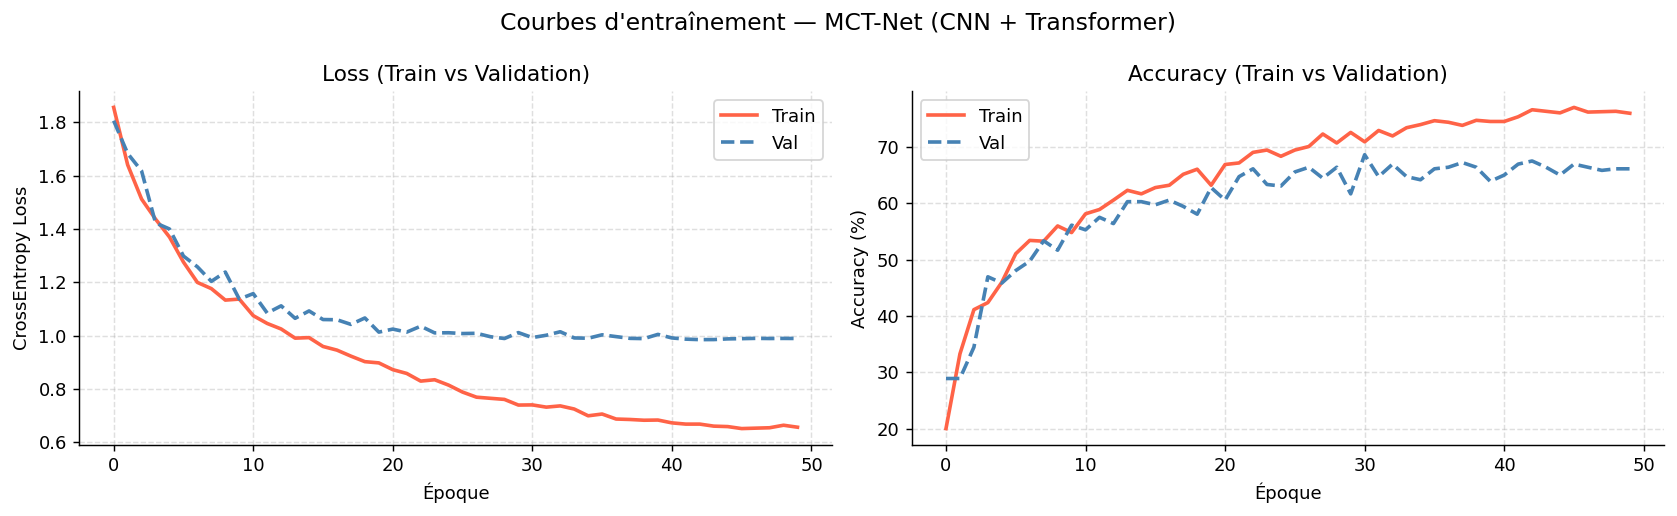

Loss finale  (train) : 0.6564  |  (val) : 0.9892
Acc finale   (train) : 75.97%  |  (val) : 66.11%


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history['loss'],     color='tomato',    linewidth=2, label='Train')
axes[0].plot(history['val_loss'], color='steelblue', linewidth=2, label='Val', linestyle='--')
axes[0].set_title('Loss (Train vs Validation)')
axes[0].set_xlabel('Époque')
axes[0].set_ylabel('CrossEntropy Loss')
axes[0].legend()

axes[1].plot(history['accuracy'],     color='tomato',    linewidth=2, label='Train')
axes[1].plot(history['val_accuracy'], color='steelblue', linewidth=2, label='Val', linestyle='--')
axes[1].set_title('Accuracy (Train vs Validation)')
axes[1].set_xlabel('Époque')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()

plt.suptitle('Courbes d\'entraînement — MCT-Net (CNN + Transformer)', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Loss finale  (train) : {history["loss"][-1]:.4f}  |  (val) : {history["val_loss"][-1]:.4f}')
print(f'Acc finale   (train) : {history["accuracy"][-1]:.2f}%  |  (val) : {history["val_accuracy"][-1]:.2f}%')

### 🧪 Évaluation sur le jeu de TEST

In [16]:
model.eval()
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(DEVICE)

with torch.no_grad():
    outputs = model(X_test_t)
    _, predicted = torch.max(outputs, 1)
    test_acc = 100 * (predicted == y_test_t).sum().item() / len(y_test_t)

print(f'\n🎯 Accuracy sur le jeu de TEST : {test_acc:.2f}%')


🎯 Accuracy sur le jeu de TEST : 72.60%


### 💾 Sauvegarde du modèle

In [17]:
torch.save({
    'model_state_dict' : model.state_dict(),
    'num_classes'      : num_classes,
    'label_classes'    : list(le.classes_),
    'history'          : history,
    'test_accuracy'    : test_acc,
    'n_dates'          : N_DATES,
    'n_bands'          : N_BANDS,
}, MODEL_PATH)

print(f'✅ Modèle sauvegardé : {MODEL_PATH}')
print(f'   Accuracy test     : {test_acc:.2f}%')
print('\n🎉 Pipeline MCT-Net complet terminé !')

✅ Modèle sauvegardé : models\mctnet_multispectral_final.pth
   Accuracy test     : 72.60%

🎉 Pipeline MCT-Net complet terminé !
